## Loading the Dataset and Splitting it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

# AT  -> Temperature
# V   -> Vaccuum
# AP  -> Pressure
# RH  -> Humidity

# PE  -> Produced Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Converting the data into tensors

In [8]:
import torch
import torch.nn as nn  

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


In [10]:
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled, dtype=torch.float32
)

In [11]:
y_train_tensor = torch.tensor(
    y_train.values, dtype=torch.float32
).view(-1,1)

y_test_tensor = torch.tensor(
    y_test.values, dtype=torch.float32
).view(-1,1)

# we are using .values because y_train values are in pandas series
# .view() is used to change the shape of y_train to -1 rows (i.e., it detects it automatically) and 1 column

## Creating the TensorDataset and DataLoader

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Defining the ANN model

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer (have 4 inputs and 6 outputs)
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer (have 6 inputs and 6 outputs)
            nn.Linear(6,6),
            nn.ReLU(),
    
            # Output Layer (have 6 inputs and 1 output)
            nn.Linear(6,1)
        )

    def forward(self, x):
        return self.model(x)

In [15]:
import torch.optim as optim

model = ANN().to(device)

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## Train the ANN and save the best Params of the model

In [16]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")

epochs = 50

for epoch in range(epochs):
    model.train
    running_loss = 0.0  # total running loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb -> input features of each batch
        # yb -> label of each batch
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()  # to remove the previously stored gradients of the previous batch 
        
        outputs = model(xb)  # forward propagation -> predicted outputs for this batch
        loss = criterion(outputs, yb)  # compute loss
        loss.backward()  # backward propagation -> compute the gradients
        optimizer.step()  # updates the parameters like weights, bias

        running_loss += loss.item()  # .item() converts the loss from a tensor to a py float

    epoch_train_loss = running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():    # dont compute any gradients
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch: {epoch+1}/{epochs} => \nTrain Loss = {epoch_train_loss} \nValidation Loss = {epoch_val_loss} \n\n") 

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")  # .pt or .pth files save the best parameters of the model)

epoch: 1/50 => 
Train Loss = 205282.42897135418 
Validation Loss = 202263.03932291668 


epoch: 2/50 => 
Train Loss = 192336.96751302082 
Validation Loss = 176977.9359375 


epoch: 3/50 => 
Train Loss = 151467.5633138021 
Validation Loss = 123448.71171875 


epoch: 4/50 => 
Train Loss = 95412.51739908854 
Validation Loss = 71843.04192708334 


epoch: 5/50 => 
Train Loss = 55638.08440755208 
Validation Loss = 43164.53984375 


epoch: 6/50 => 
Train Loss = 33420.35868326823 
Validation Loss = 25130.642122395835 


epoch: 7/50 => 
Train Loss = 18943.48330078125 
Validation Loss = 13823.75947265625 


epoch: 8/50 => 
Train Loss = 10954.486999511719 
Validation Loss = 8524.963216145834 


epoch: 9/50 => 
Train Loss = 7238.866935221354 
Validation Loss = 5831.178723144531 


epoch: 10/50 => 
Train Loss = 5014.515250651041 
Validation Loss = 4153.5051961263025 


epoch: 11/50 => 
Train Loss = 3583.208005777995 
Validation Loss = 2990.8381205240885 


epoch: 12/50 => 
Train Loss = 2596.7630879

## Plotting the Losses

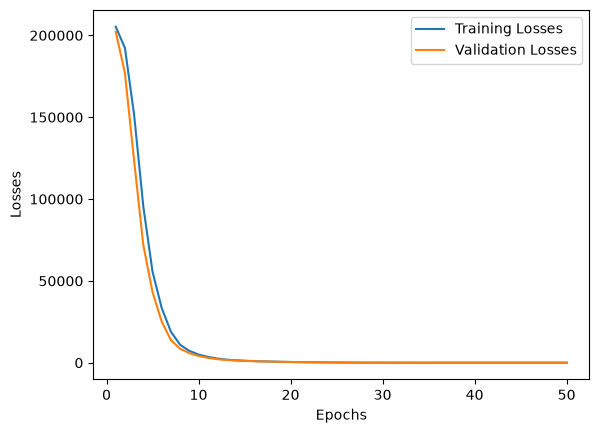

In [18]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

sns.lineplot(x= range(1, epochs+1), y=loss_df["Training Loss"], label = "Training Losses")
sns.lineplot(x= range(1, epochs+1), y=loss_df["Validation Loss"], label = "Validation Losses")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

## Loading the best model

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluation of the Model

In [21]:
model.eval()

with torch.no_grad():
    X_train_tensor = X_train_tensor.to(device)
    X_test_tensor = X_test_tensor.to(device)
    y_train_tensor = y_train_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)

    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.447372436523438
Testing MSE: 20.398494720458984


In [25]:
from sklearn.metrics import r2_score

print("r2 score:", r2_score(y_test, test_preds.cpu().numpy()))

r2 score: 0.9287125290755358


In [28]:
predicted_df = pd.DataFrame(test_preds.cpu().numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.811340,433.27
1,437.925293,438.16
2,460.930847,458.42
3,475.943970,480.82
4,435.545776,441.41
...,...,...
1909,451.836975,456.70
1910,432.446350,438.04
1911,467.682190,467.80
1912,431.971863,437.14
